In [36]:
from matplotlib import pyplot as plt
import ee
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.cm as cm
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm
import string

import sys

# append (..)
sys.path.append("..")

from utils.plotting_utils import (
    get_geometries,
    get_color_palettes,
    url_to_image,
    blend_geom_to_img,
    get_imgc,
)

ee.Initialize(project="ee-speckerfelix")

colors = get_color_palettes()


In [37]:
geometries = get_geometries()["point_geoms_figs3"]

# buffer/bbox (tune buffer_m)
buffer_m = 1500
site_bbox = {k: g.buffer(buffer_m).bounds() for k, g in geometries.items()}

In [38]:
# -------------------------
# 2) Pick trait/year/res + get collection
# -------------------------
trait = "laie"  # or fapar/fcover/etc
year = 2022
resolution = "20m"
version = "v03-figures"

imgc = get_imgc(trait, resolution=resolution, year=year, version=version)


# Bands you want to show (edit names to match yours!)
band_map = {
    "mean": f"{trait}_mean",
    "stdDev": f"{trait}_stdDev",  # or f"{trait}_std"
    "stdDev_within": f"{trait}_stdDev_within",
    "stdDev_across": f"{trait}_stdDev_across",
}

col_order = ["mean", "stdDev", "stdDev_within", "stdDev_across"]
col_order = ["s2_rgb"] + list(col_order)

# Optional scaling (keep consistent with how you exported the trait)
# Set to 1.0 if your bands are already in physical units.
scale_factor = {
    "mean": 1000.0,  # example: LAI stored as int*1000
    "stdDev": 1000.0,
    "stdDev_within": 1000.0,
    "stdDev_across": 1000.0,
}


In [39]:
print(imgc.size().getInfo())

4


In [40]:
# -------------------------
# 3) Vis params per row (shared across columns)
# -------------------------
# Reuse your palettes/norms; placeholders below assume you already have norms/cmaps.
# Recommended: same cmap for all std rows (e.g. std_cmap), different norm per component if needed.
vis = {
    "s2_rgb": {
        "min": 0,
        "max": 2500,
        "gamma": 1.2,
        "bands": ["B4", "B3", "B2"],
    },
    "mean": {
        **colors[f"{trait}_visparams"],  # min/max/palette if you store them there
        "cmap": colors[f"{trait}_cmap"],
        "norm": colors[f"{trait}_norm"],
    },
    "stdDev": {
        **colors[f"{trait}_std_visparams"],
        "cmap": colors["std_cmap"],
        "norm": colors[f"std_{trait}_norm"],
    },
    "stdDev_within": {
        # you may want separate norms for within/across to avoid saturating
        **colors.get(f"{trait}_std_within_visparams", colors[f"{trait}_std_visparams"]),
        "cmap": colors["std_cmap"],
        "norm": colors.get(f"std_within_{trait}_norm", colors[f"std_{trait}_norm"]),
    },
    "stdDev_across": {
        **colors.get(f"{trait}_std_across_visparams", colors[f"{trait}_std_visparams"]),
        "cmap": colors["std_cmap"],
        "norm": colors.get(f"std_across_{trait}_norm", colors[f"std_{trait}_norm"]),
    },
}


In [41]:
# -------------------------
# 4) Helper: make thumb URL for (site, row)
# -------------------------
def thumb_url_for(site_key, row_key, dims=512):
    band = band_map[row_key]
    img = imgc.select(band).filterBounds(geometries[site_key]).mosaic()

    # scale to physical units if needed
    img = img.divide(scale_factor[row_key])

    # blend site outline if you like (optional)
    img_rgb = blend_geom_to_img(
        img,
        geometries[site_key],
        img_vis={
            k: v for k, v in vis[row_key].items() if k in ["min", "max", "palette"]
        },
        geom_vis={"palette": "yellow"},
        width=4,
    )

    return img_rgb.getThumbURL(
        {"region": site_bbox[site_key], "dimensions": f"{dims}x{dims}"}
    )


S2_IMGC = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterDate("2020-01-01", "2020-12-31")
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20))
)


def thumb_url_s2(site_key, dims=512):
    # q25 mosaic
    s2_img = (
        S2_IMGC.select(["B4", "B3", "B2"])
        .filterBounds(geometries[site_key])
        .reduce(ee.Reducer.percentile([25]))
        .rename(["B4", "B3", "B2"])
    )

    img_rgb = blend_geom_to_img(
        s2_img,
        geometries[site_key],
        img_vis=vis["s2_rgb"],
        geom_vis={"palette": "yellow"},
        width=4,
    )

    return img_rgb.getThumbURL(
        {"region": site_bbox[site_key], "dimensions": f"{dims}x{dims}"}
    )

In [42]:
# find MGRS tiles for the sites:
mgrs_tiles = []
for site in geometries.keys():
    s2_imgc = (
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterBounds(geometries[site])
        .filterDate("2022-01-01", "2022-01-31")
    )
    mgrs_tiles.append(s2_imgc.aggregate_array("MGRS_TILE").distinct().getInfo())

print(mgrs_tiles)

[['34NDG'], ['10UCU', '10UDU'], ['35LMH'], ['32UNA', '32UPA']]


<>:19: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.
<>:20: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.
<>:21: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.
<>:19: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.
<>:20: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.
<>:21: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.


/var/folders/83/2r2r5qp14398cnm45nnlt7080000gn/T/ipykernel_39266/1102694130.py:19: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.
  "stdDev": "$LAIe \ \sigma_{\mathrm{total}}$",
/var/folders/83/2r2r5qp14398cnm45nnlt7080000gn/T/ipykernel_39266/1102694130.py:20: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.
  "stdDev_within": "$LAIe \ \sigma_{\mathrm{within}}$",
/var/folders/83/2r2r5qp14398cnm45nnlt7080000gn/T/ipykernel_39266/1102694130.py:21: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.
  "stdDev_across": "$LAIe \ \sigma_{\mathrm{across}}$",


https://earthengine.googleapis.com/v1/projects/ee-speckerfelix/thumbnails/c0273c2b537310e85a8fc8e1567f484b-44fc51a45748b0ae0ea094a5666ae305:getPixels
https://earthengine.googleapis.com/v1/projects/ee-speckerfelix/thumbnails/21454872f2c3f18b88e7714ae021946d-3cb8da95a9924518ce8ef9dbfa5f7792:getPixels
https://earthengine.googleapis.com/v1/projects/ee-speckerfelix/thumbnails/3759a9fa3ab1c201c2ce42a6dda04af5-6d1424865851f570ff1fc8af213d99ad:getPixels
https://earthengine.googleapis.com/v1/projects/ee-speckerfelix/thumbnails/5deb118ae7cfbd5e6088932481f276ec-326d4b5b27e175ce7da6d948e8f39000:getPixels
https://earthengine.googleapis.com/v1/projects/ee-speckerfelix/thumbnails/dcb6bd252d63805683ee6966dffbe781-a697d00061d90be4679b609abb441abb:getPixels
https://earthengine.googleapis.com/v1/projects/ee-speckerfelix/thumbnails/6786b04e444cee83fcb44b52c52d3a97-29369e6e067369acb92ce6bf073eee84:getPixels
https://earthengine.googleapis.com/v1/projects/ee-speckerfelix/thumbnails/42e1fc46495eae3c423445b621

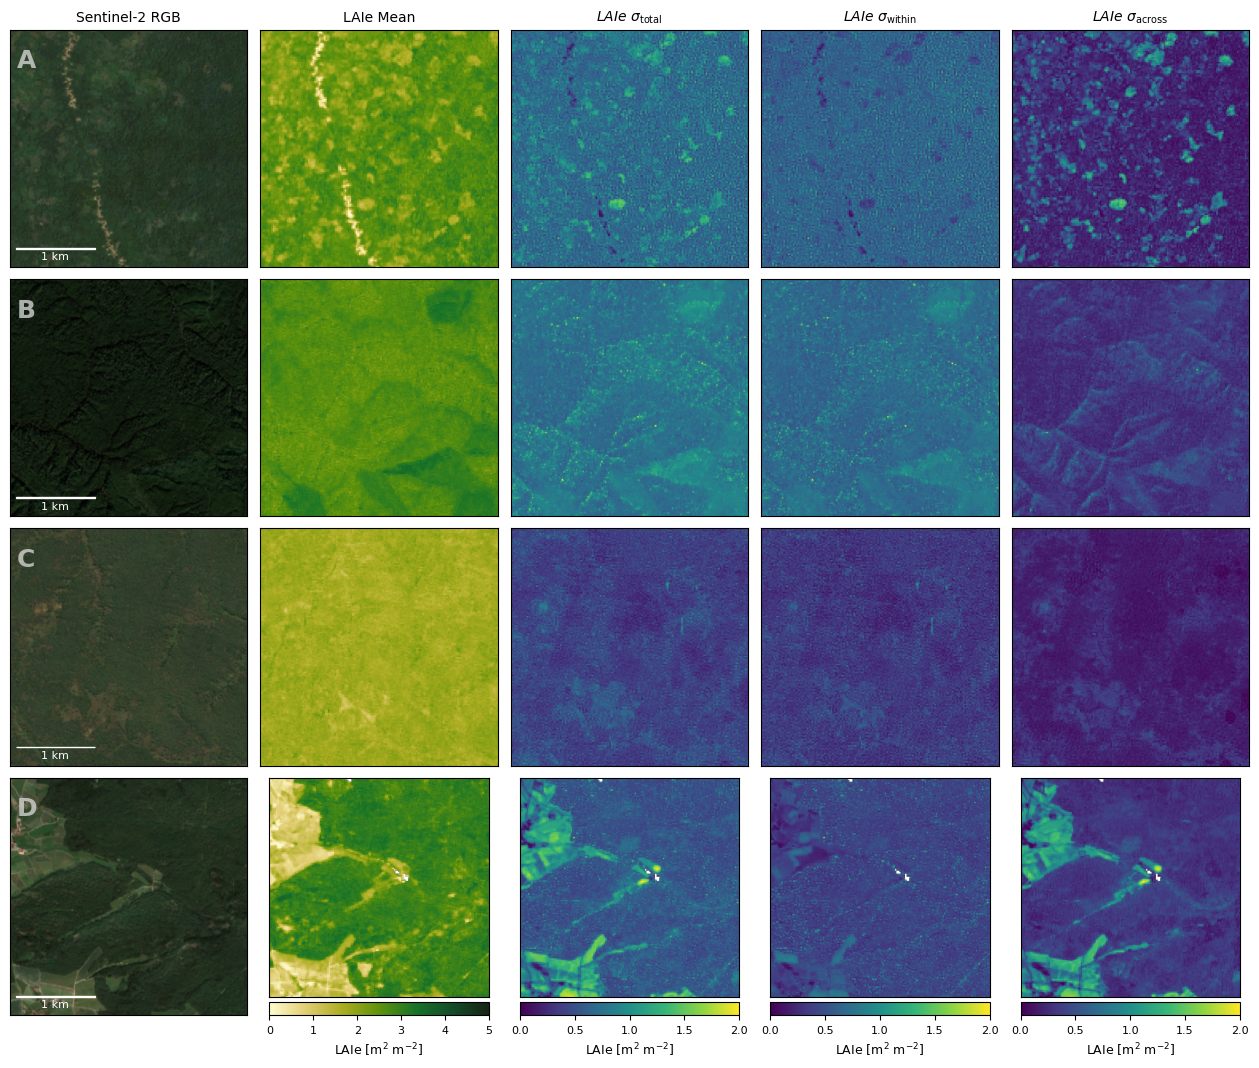

In [45]:
# -------------------------
# 5) Plot: 4 rows × 4 cols
# -------------------------
nrows = len(geometries)
ncols = len(col_order)

fig, axs = plt.subplots(
    nrows,
    ncols,
    figsize=(3.2 * ncols, 3.2 * nrows),
    gridspec_kw={"hspace": 0.05, "wspace": 0.05},
)


# Col labels
col_labels = {
    "s2_rgb": "Sentinel-2 RGB",
    "mean": "LAIe Mean",
    "stdDev": "$LAIe \ \sigma_{\mathrm{total}}$",
    "stdDev_within": "$LAIe \ \sigma_{\mathrm{within}}$",
    "stdDev_across": "$LAIe \ \sigma_{\mathrm{across}}$",
}

# Column titles
for j, band_key in enumerate(col_order):
    axs[0, j].set_title(col_labels[band_key], fontsize=10)

row_sites = list(geometries.keys())
# for i, site_name in enumerate(row_sites):
#     axs[i, 0].set_ylabel(site_name, fontsize=10)

for i, site_key in enumerate(row_sites):  # rows = sites
    for j, band_key in enumerate(col_order):  # cols = bands
        if band_key == "s2_rgb":
            url = thumb_url_s2(site_key)
            print(url)

            # add scale bar to left column
            ax = axs[i, j]

            total_image_size_meters = buffer_m * 2
            pixel_size = total_image_size_meters / 512  # assuming 512x512 images

            scalebar = AnchoredSizeBar(
                ax.transData,
                1000 / pixel_size,  # length in pixels (e.g. 1000 m)
                "1 km",  # label
                loc="lower left",
                pad=0.4,
                color="white",
                frameon=False,
                size_vertical=2,
                fontproperties=fm.FontProperties(size=8),
            )

            ax.add_artist(scalebar)
        else:
            url = thumb_url_for(site_key, band_key)
            print(url)
        ax = axs[i, j]
        ax.set_xticks([])
        ax.set_yticks([])
        ax.imshow(url_to_image(url))

for j, band_key in enumerate(col_order):
    if band_key == "s2_rgb":
        continue
    ax = axs[-1, j]  # bottom row
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("bottom", size="6%", pad=0.05)

    sm = cm.ScalarMappable(
        norm=vis[band_key]["norm"],
        cmap=vis[band_key]["cmap"],
    )
    cb = fig.colorbar(sm, cax=cax, orientation="horizontal")
    cb.ax.tick_params(labelsize=8)

    # add units
    cb.set_label(r"LAIe [m$^2$ m$^{-2}$]", fontsize=9)


row_labels = list(string.ascii_uppercase[:nrows])  # ['A','B','C','D']

for i in range(nrows):
    ax = axs[i, 0]  # first column only

    ax.text(
        0.03,
        0.92,  # top-left inside panel
        row_labels[i],
        transform=ax.transAxes,
        fontsize=18,  # large but subtle
        fontweight="bold",
        color="lightgrey",
        alpha=0.8,
        ha="left",
        va="top",
    )


# # add scale bar to left column
# from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
# import matplotlib.font_manager as fm

# ax = axs[-1, 0]

# total_image_size_meters = buffer_m * 2
# pixel_size = total_image_size_meters / 512 # assuming 512x512 images

# scalebar = AnchoredSizeBar(
#     ax.transData,
#     1000 / pixel_size,  # length in pixels (e.g. 1000 m)
#     "1 km",  # label
#     loc="lower left",
#     pad=0.4,
#     color="white",
#     frameon=False,
#     size_vertical=2,
#     fontproperties=fm.FontProperties(size=8),
# )

# ax.add_artist(scalebar)


In [46]:
fig.set_size_inches(10.1, 8.1)  # ~18 cm wide, square-ish
fig.savefig("figure-s3.png", dpi=300, bbox_inches="tight")

fig.savefig("figure-s3.pdf", bbox_inches="tight")
